In [2]:
import numpy as np

# Replace these with the actual filenames you have
file_a = np.load('traces.npy') 
file_b = np.load('plaintexts.npy')
print(f"File A shape: {file_a.shape}")
print(f"File B shape: {file_b.shape}")

File A shape: (7500, 1000)
File B shape: (7500, 4)


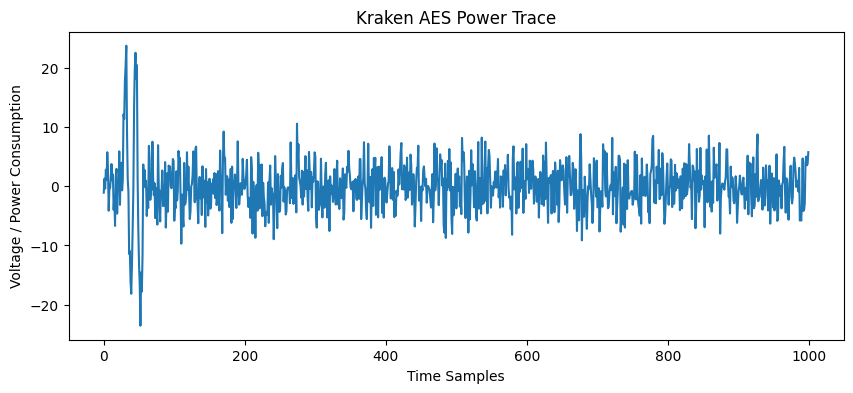

In [3]:
import matplotlib.pyplot as plt

# Assuming file_a is your traces array (the large 2D matrix)
plt.figure(figsize=(10, 4))
plt.plot(file_a[0]) # Plot the very first encryption trace
plt.title("Kraken AES Power Trace")
plt.xlabel("Time Samples")
plt.ylabel("Voltage / Power Consumption")
plt.show()

In [4]:
import numpy as np

# 1. Load the chaos
plaintexts = np.load('plaintexts.npy')
traces = np.load('traces.npy')

num_traces, num_samples = traces.shape

print("[+] Lore translated: 'The first beacon is secure.' -> Trace 0 is the clean reference.")
print("[+] Lore translated: 'Throwing into chaos.' -> Traces are randomly shifted in time.")

# 2. Trace Alignment (Cross-Correlation Synchronization)
aligned_traces = np.zeros_like(traces)

# You previously plotted Trace 0 and saw the wave was between samples 30 and 80.
# We will use this exact window as our alignment template!
ref_window = traces[0, 30:80]

print("\n[+] Re-aligning traces (clearing the chaos)...")
for i in range(num_traces):
    # Search for the reference window inside the current trace
    corr = np.correlate(traces[i], ref_window, mode='valid')
    best_start = np.argmax(corr)
    
    # In Trace 0, the wave starts at 30. If it starts at 45 in Trace 1, it's shifted right by 15.
    shift = best_start - 30 
    
    # Roll the trace backward to lock it into perfect synchronization with Trace 0
    aligned_traces[i] = np.roll(traces[i], -shift)

# Center the newly synchronized data for Pearson math
traces_diff = aligned_traces - np.mean(aligned_traces, axis=0)

# 3. Crypto Setup
AES_SBOX = np.array([
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5, 0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,
    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0, 0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,
    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc, 0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,
    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a, 0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,
    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0, 0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,
    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b, 0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,
    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85, 0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,
    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5, 0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,
    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17, 0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,
    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88, 0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,
    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c, 0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,
    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9, 0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,
    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6, 0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,
    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e, 0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,
    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94, 0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,
    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68, 0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
], dtype=np.uint8)

HW = np.array([bin(n).count("1") for n in range(256)], dtype=np.uint8)

# "in the instant it shifts its state, it releases energy"
models = {
    "Standard Leakage (HW SBox)": lambda p, k: HW[AES_SBOX[p ^ k]],
    "State Shift Leakage (HD Plaintext -> SBox)": lambda p, k: HW[p ^ AES_SBOX[p ^ k]]
}

print("\n[+] Running CPA on synchronized traces...")
for name, func in models.items():
    print(f"\n--- Testing Model: {name} ---")
    recovered_key = []
    
    for b_idx in range(4):
        hypo_hw = np.zeros((num_traces, 256))
        for k_guess in range(256):
            hypo_hw[:, k_guess] = func(plaintexts[:, b_idx], k_guess)
            
        hw_diff = hypo_hw - np.mean(hypo_hw, axis=0)
        numerator = np.dot(hw_diff.T, traces_diff)
        denominator = np.sqrt(np.sum(hw_diff**2, axis=0)[:, None]) * np.sqrt(np.sum(traces_diff**2, axis=0)[None, :])
        corr_matrix = np.abs(np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0))
        
        # Grab the highest correlation peak
        best_guess, best_sample = np.unravel_index(np.argmax(corr_matrix), corr_matrix.shape)
        max_val = corr_matrix[best_guess, best_sample]
        
        recovered_key.append(best_guess)
        print(f"Byte {b_idx}: 0x{best_guess:02X} (Correlation: {max_val:.4f} at Sample {best_sample})")
        
    hex_key = "".join(f"{b:02X}" for b in recovered_key)
    print(f"-> Derived Key: 0x{hex_key}")

[+] Lore translated: 'The first beacon is secure.' -> Trace 0 is the clean reference.
[+] Lore translated: 'Throwing into chaos.' -> Traces are randomly shifted in time.

[+] Re-aligning traces (clearing the chaos)...

[+] Running CPA on synchronized traces...

--- Testing Model: Standard Leakage (HW SBox) ---
Byte 0: 0x4F (Correlation: 0.0819 at Sample 87)
Byte 1: 0xF3 (Correlation: 0.0725 at Sample 177)
Byte 2: 0xE7 (Correlation: 0.0606 at Sample 227)
Byte 3: 0x11 (Correlation: 0.0619 at Sample 246)
-> Derived Key: 0x4FF3E711

--- Testing Model: State Shift Leakage (HD Plaintext -> SBox) ---
Byte 0: 0x9A (Correlation: 0.3046 at Sample 127)
Byte 1: 0xD0 (Correlation: 0.2921 at Sample 177)
Byte 2: 0xBE (Correlation: 0.2873 at Sample 227)
Byte 3: 0x39 (Correlation: 0.2796 at Sample 277)
-> Derived Key: 0x9AD0BE39


### Flag: CCDC2026{0x9AD0BE39}